<a href="https://colab.research.google.com/github/Shiva-panda/MODEL-implementation/blob/main/LASSSO%2CRIDGE%2CELASTIC_NET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## L1 Regularization (Lasso Regression)

### Objective Function

$$
J = \frac{1}{n} \sum (y - \hat{y})^2 + \lambda \sum |b_i|
$$

---

### Key Idea

- Adds penalty = sum of absolute values of coefficients
- Forces some coefficients to become exactly 0 (feature selection)

In [1]:
from sklearn.linear_model import Lasso
import numpy as np

X = np.array([[1], [2], [3], [4], [5]])
y = np.array([2, 4, 5, 4, 5])

model = Lasso(alpha=0.1)  # alpha = lambda
model.fit(X, y)

y_pred = model.predict(X)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 2.3499999999999996
Coefficients: [0.55]


## L2 Regularization (Ridge Regression)

### Objective Function

$$
J = \frac{1}{n} \sum (y - \hat{y})^2 + \lambda \sum b_i^2
$$

---

### Key Idea

- Adds penalty = square of coefficients
- Shrinks coefficients but never makes them exactly 0

In [2]:
from sklearn.linear_model import Ridge
import numpy as np

X = np.array([[1], [2], [3], [4], [5]])
y = np.array([2, 4, 5, 4, 5])

model = Ridge(alpha=0.1)
model.fit(X, y)

y_pred = model.predict(X)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 2.217821782178218
Coefficients: [0.59405941]


## Elastic Net Regression

### Objective Function

$$
J = \frac{1}{n} \sum (y - \hat{y})^2
+ \lambda_1 \sum |b_i|
+ \lambda_2 \sum b_i^2
$$

---

### Key Idea

- Combines L1 and L2
- Balances feature selection + coefficient shrinkage

In [3]:
from sklearn.linear_model import ElasticNet
import numpy as np

X = np.array([[1], [2], [3], [4], [5]])
y = np.array([2, 4, 5, 4, 5])

model = ElasticNet(alpha=0.1, l1_ratio=0.5)
model.fit(X, y)

y_pred = model.predict(X)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 2.317073170731707
Coefficients: [0.56097561]


Linear Regression
Intercept: 3.1288861844059497
Coefficient: 1.8840332010163545
------------------------------
Ridge Regression
Intercept: 3.738377558854461
Coefficient: 1.7621349261266523
------------------------------
Lasso Regression
Intercept: 4.281827360876537
Coefficient: 1.653444965722237
------------------------------
Elastic Net
Intercept: 4.619578450754065
Coefficient: 1.5858947477467316
------------------------------


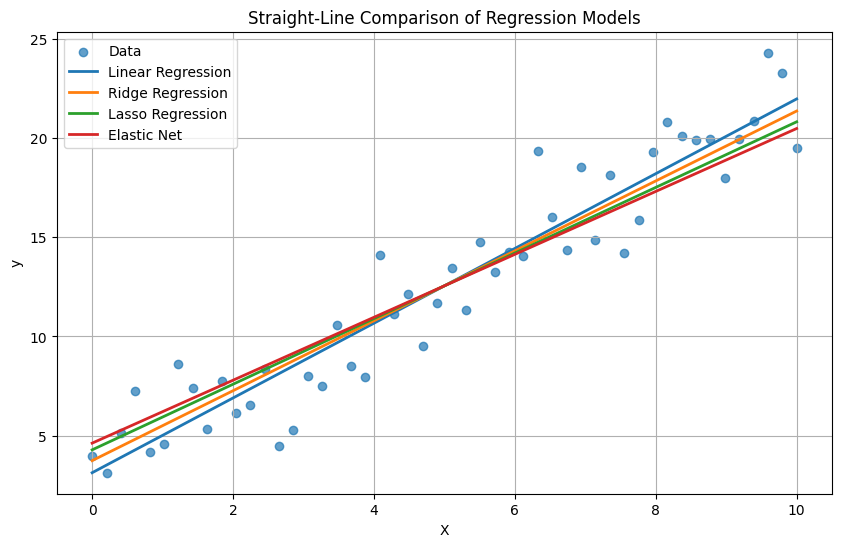

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

np.random.seed(42)

X = np.linspace(0, 10, 50).reshape(-1, 1)
y = 2 * X.squeeze() + 3 + np.random.normal(0, 2, size=50)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=30.0),
    "Lasso Regression": Lasso(alpha=2.0),
    "Elastic Net": ElasticNet(alpha=2.0, l1_ratio=0.5)
}

plt.figure(figsize=(10, 6))
plt.scatter(X, y, label="Data", alpha=0.7)

X_plot = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)

for name, model in models.items():
    model.fit(X, y)
    y_plot = model.predict(X_plot)
    print(f"{name}")
    print("Intercept:", model.intercept_)
    print("Coefficient:", model.coef_[0])
    print("-" * 30)
    plt.plot(X_plot, y_plot, linewidth=2, label=name)

plt.title("Straight-Line Comparison of Regression Models")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
import numpy as np
import plotly.graph_objects as go
from sklearn.linear_model import Ridge

np.random.seed(42)

X = np.linspace(0, 10, 50).reshape(-1, 1)
y = 2 * X.squeeze() + 3 + np.random.normal(0, 2, size=50)

X_plot = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)

alphas = [0.01, 0.1, 1, 5, 10, 30, 60, 100]
frames = []

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X, y)
    y_pred = model.predict(X_plot)

    frames.append(
        go.Frame(
            data=[
                go.Scatter(x=X.squeeze(), y=y, mode="markers", name="Data"),
                go.Scatter(x=X_plot.squeeze(), y=y_pred, mode="lines", name=f"Ridge alpha={alpha}")
            ],
            name=str(alpha)
        )
    )

fig = go.Figure(
    data=[
        go.Scatter(x=X.squeeze(), y=y, mode="markers", name="Data"),
        go.Scatter(
            x=X_plot.squeeze(),
            y=frames[0].data[1].y,
            mode="lines",
            name=f"Ridge alpha={alphas[0]}"
        )
    ],
    layout=go.Layout(
        title="Ridge Regression: Effect of Alpha",
        xaxis=dict(title="X"),
        yaxis=dict(title="y"),
        updatemenus=[
            {
                "type": "buttons",
                "buttons": [
                    {
                        "label": "Play",
                        "method": "animate",
                        "args": [
                            None,
                            {
                                "frame": {"duration": 900, "redraw": True},
                                "fromcurrent": True
                            }
                        ]
                    }
                ]
            }
        ]
    ),
    frames=frames
)

fig.show()

## Comparison of Linear, Ridge, Lasso, and Elastic Net

We generate a proper linear dataset:

$$
y = 2x + 3 + \text{noise}
$$

Then we compare:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Elastic Net Regression

### Linear Regression
$$
\hat{y} = b_0 + b_1 x
$$

### Ridge Regression
$$
J = \frac{1}{n} \sum (y - \hat{y})^2 + \lambda \sum b_i^2
$$

### Lasso Regression
$$
J = \frac{1}{n} \sum (y - \hat{y})^2 + \lambda \sum |b_i|
$$

### Elastic Net
$$
J = \frac{1}{n} \sum (y - \hat{y})^2 + \lambda_1 \sum |b_i| + \lambda_2 \sum b_i^2
$$

As regularization increases, Ridge, Lasso, and Elastic Net shrink the slope of the line.

In [11]:
import numpy as np
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# -----------------------------
# 1. Create proper linear data
# -----------------------------
np.random.seed(42)
X = np.linspace(0, 10, 50).reshape(-1, 1)
y = 2 * X.squeeze() + 3 + np.random.normal(0, 2, size=50)

X_plot = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)

# -----------------------------
# 2. Define alpha values
# -----------------------------
alphas = [0.01, 0.1, 0.5, 1, 2, 5, 10, 20, 40, 80]

# -----------------------------
# 3. Fit base linear regression once
# -----------------------------
linear_model = LinearRegression()
linear_model.fit(X, y)
y_linear = linear_model.predict(X_plot)

# -----------------------------
# 4. Build frames
# -----------------------------
frames = []

for alpha in alphas:
    ridge_model = Ridge(alpha=alpha)
    lasso_model = Lasso(alpha=alpha, max_iter=10000)
    elastic_model = ElasticNet(alpha=alpha, l1_ratio=0.5, max_iter=10000)

    ridge_model.fit(X, y)
    lasso_model.fit(X, y)
    elastic_model.fit(X, y)

    y_ridge = ridge_model.predict(X_plot)
    y_lasso = lasso_model.predict(X_plot)
    y_elastic = elastic_model.predict(X_plot)

    frames.append(
        go.Frame(
            data=[
                go.Scatter(
                    x=X.squeeze(), y=y,
                    mode="markers",
                    name="Data",
                    marker=dict(color="black", size=8)
                ),
                go.Scatter(
                    x=X_plot.squeeze(), y=y_linear,
                    mode="lines",
                    name="Linear Regression",
                    line=dict(color="blue", width=3)
                ),
                go.Scatter(
                    x=X_plot.squeeze(), y=y_ridge,
                    mode="lines",
                    name="Ridge Regression",
                    line=dict(color="red", width=3)
                ),
                go.Scatter(
                    x=X_plot.squeeze(), y=y_lasso,
                    mode="lines",
                    name="Lasso Regression",
                    line=dict(color="green", width=3)
                ),
                go.Scatter(
                    x=X_plot.squeeze(), y=y_elastic,
                    mode="lines",
                    name="Elastic Net",
                    line=dict(color="orange", width=3)
                )
            ],
            name=str(alpha),
            layout=go.Layout(
                title=f"Linear vs Ridge vs Lasso vs Elastic Net | alpha = {alpha}"
            )
        )
    )

# -----------------------------
# 5. Initial frame
# -----------------------------
first_alpha = alphas[0]

ridge_model = Ridge(alpha=first_alpha)
lasso_model = Lasso(alpha=first_alpha, max_iter=10000)
elastic_model = ElasticNet(alpha=first_alpha, l1_ratio=0.5, max_iter=10000)

ridge_model.fit(X, y)
lasso_model.fit(X, y)
elastic_model.fit(X, y)

y_ridge = ridge_model.predict(X_plot)
y_lasso = lasso_model.predict(X_plot)
y_elastic = elastic_model.predict(X_plot)

fig = go.Figure(
    data=[
        go.Scatter(
            x=X.squeeze(), y=y,
            mode="markers",
            name="Data",
            marker=dict(color="black", size=8)
        ),
        go.Scatter(
            x=X_plot.squeeze(), y=y_linear,
            mode="lines",
            name="Linear Regression",
            line=dict(color="blue", width=3)
        ),
        go.Scatter(
            x=X_plot.squeeze(), y=y_ridge,
            mode="lines",
            name="Ridge Regression",
            line=dict(color="red", width=3)
        ),
        go.Scatter(
            x=X_plot.squeeze(), y=y_lasso,
            mode="lines",
            name="Lasso Regression",
            line=dict(color="green", width=3)
        ),
        go.Scatter(
            x=X_plot.squeeze(), y=y_elastic,
            mode="lines",
            name="Elastic Net",
            line=dict(color="orange", width=3)
        )
    ],
    layout=go.Layout(
        title=f"Linear vs Ridge vs Lasso vs Elastic Net | alpha = {first_alpha}",
        xaxis=dict(title="X"),
        yaxis=dict(title="y"),
        updatemenus=[
            {
                "type": "buttons",
                "showactive": False,
                "buttons": [
                    {
                        "label": "Play",
                        "method": "animate",
                        "args": [
                            None,
                            {
                                "frame": {"duration": 1000, "redraw": True},
                                "fromcurrent": True,
                                "transition": {"duration": 400}
                            }
                        ]
                    },
                    {
                        "label": "Pause",
                        "method": "animate",
                        "args": [
                            [None],
                            {
                                "frame": {"duration": 0, "redraw": False},
                                "mode": "immediate",
                                "transition": {"duration": 0}
                            }
                        ]
                    }
                ]
            }
        ],
        sliders=[
            {
                "steps": [
                    {
                        "method": "animate",
                        "label": str(alpha),
                        "args": [
                            [str(alpha)],
                            {
                                "frame": {"duration": 800, "redraw": True},
                                "mode": "immediate",
                                "transition": {"duration": 300}
                            }
                        ]
                    }
                    for alpha in alphas
                ],
                "currentvalue": {"prefix": "alpha: "}
            }
        ]
    ),
    frames=frames
)

fig.show()

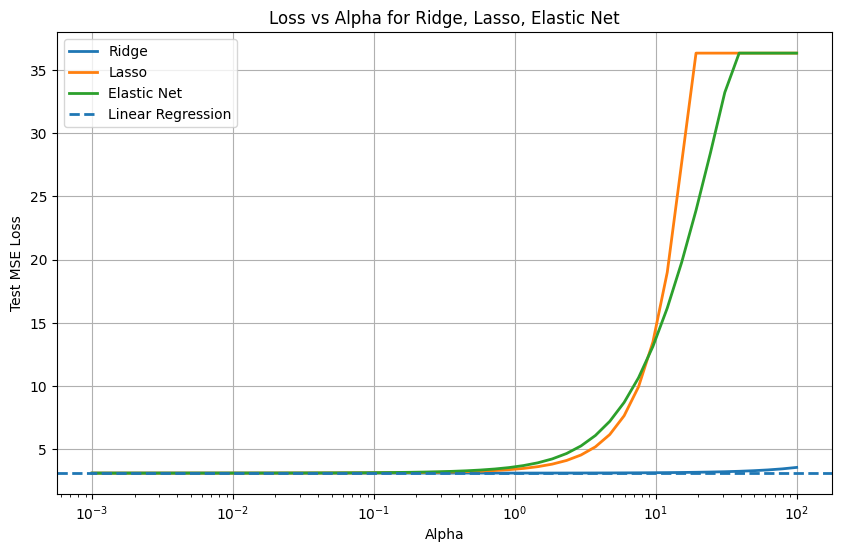

In [12]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# -----------------------------
# 1. Create proper linear dataset
# -----------------------------
np.random.seed(42)

X = np.linspace(0, 10, 200).reshape(-1, 1)
y = 2 * X.squeeze() + 3 + np.random.normal(0, 2, size=200)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# -----------------------------
# 2. Alpha values
# -----------------------------
alphas = np.logspace(-3, 2, 50)   # 0.001 to 100

ridge_losses = []
lasso_losses = []
elastic_losses = []

# -----------------------------
# 3. Linear Regression baseline
# -----------------------------
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)
linear_loss = mean_squared_error(y_test, y_pred_linear)

# -----------------------------
# 4. Compute losses for each alpha
# -----------------------------
for alpha in alphas:
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train, y_train)
    y_pred_ridge = ridge_model.predict(X_test)
    ridge_losses.append(mean_squared_error(y_test, y_pred_ridge))

    lasso_model = Lasso(alpha=alpha, max_iter=10000)
    lasso_model.fit(X_train, y_train)
    y_pred_lasso = lasso_model.predict(X_test)
    lasso_losses.append(mean_squared_error(y_test, y_pred_lasso))

    elastic_model = ElasticNet(alpha=alpha, l1_ratio=0.5, max_iter=10000)
    elastic_model.fit(X_train, y_train)
    y_pred_elastic = elastic_model.predict(X_test)
    elastic_losses.append(mean_squared_error(y_test, y_pred_elastic))

# -----------------------------
# 5. Plot
# -----------------------------
plt.figure(figsize=(10, 6))

plt.plot(alphas, ridge_losses, label="Ridge", linewidth=2)
plt.plot(alphas, lasso_losses, label="Lasso", linewidth=2)
plt.plot(alphas, elastic_losses, label="Elastic Net", linewidth=2)
plt.axhline(y=linear_loss, linestyle="--", label="Linear Regression", linewidth=2)

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Test MSE Loss")
plt.title("Loss vs Alpha for Ridge, Lasso, Elastic Net")
plt.legend()
plt.grid(True)
plt.show()

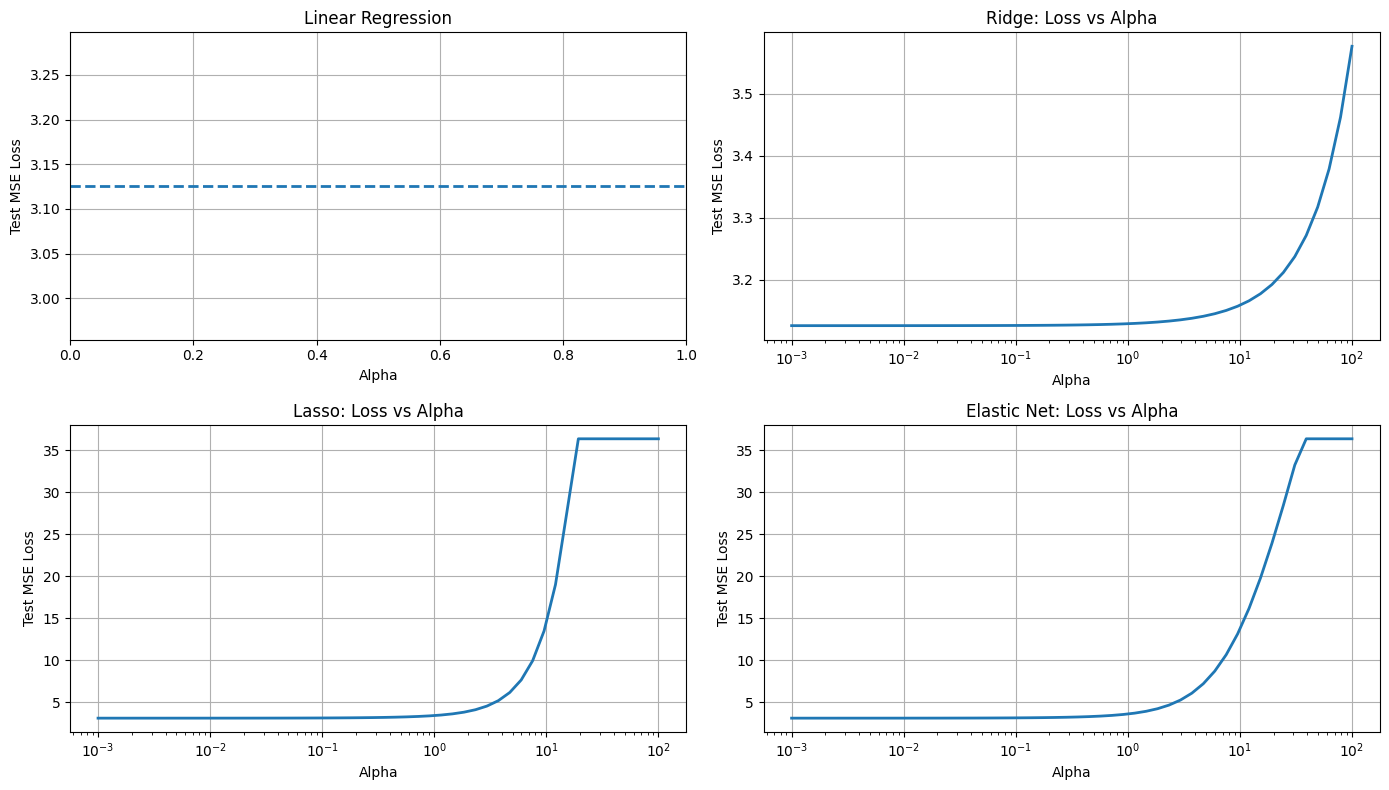

In [13]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

np.random.seed(42)

X = np.linspace(0, 10, 200).reshape(-1, 1)
y = 2 * X.squeeze() + 3 + np.random.normal(0, 2, size=200)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

alphas = np.logspace(-3, 2, 50)

ridge_losses = []
lasso_losses = []
elastic_losses = []

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_loss = mean_squared_error(y_test, linear_model.predict(X_test))

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    ridge_losses.append(mean_squared_error(y_test, ridge.predict(X_test)))

    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train, y_train)
    lasso_losses.append(mean_squared_error(y_test, lasso.predict(X_test)))

    elastic = ElasticNet(alpha=alpha, l1_ratio=0.5, max_iter=10000)
    elastic.fit(X_train, y_train)
    elastic_losses.append(mean_squared_error(y_test, elastic.predict(X_test)))

plt.figure(figsize=(14, 8))

plt.subplot(2, 2, 1)
plt.axhline(y=linear_loss, linestyle="--", linewidth=2)
plt.title("Linear Regression")
plt.xlabel("Alpha")
plt.ylabel("Test MSE Loss")
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(alphas, ridge_losses, linewidth=2)
plt.xscale("log")
plt.title("Ridge: Loss vs Alpha")
plt.xlabel("Alpha")
plt.ylabel("Test MSE Loss")
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(alphas, lasso_losses, linewidth=2)
plt.xscale("log")
plt.title("Lasso: Loss vs Alpha")
plt.xlabel("Alpha")
plt.ylabel("Test MSE Loss")
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(alphas, elastic_losses, linewidth=2)
plt.xscale("log")
plt.title("Elastic Net: Loss vs Alpha")
plt.xlabel("Alpha")
plt.ylabel("Test MSE Loss")
plt.grid(True)

plt.tight_layout()
plt.show()

In [15]:
import numpy as np
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# -----------------------------
# 1. Create proper linear data
# -----------------------------
np.random.seed(42)
X = np.linspace(0, 10, 200).reshape(-1, 1)
y = 2 * X.squeeze() + 3 + np.random.normal(0, 2, size=200)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# -----------------------------
# 2. Alpha values
# -----------------------------
alphas = np.logspace(-3, 2, 50)

ridge_losses = []
lasso_losses = []
elastic_losses = []

# Linear Regression baseline
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_loss = mean_squared_error(y_test, linear_model.predict(X_test))

# -----------------------------
# 3. Compute losses
# -----------------------------
for alpha in alphas:
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train, y_train)
    ridge_losses.append(mean_squared_error(y_test, ridge_model.predict(X_test)))

    lasso_model = Lasso(alpha=alpha, max_iter=10000)
    lasso_model.fit(X_train, y_train)
    lasso_losses.append(mean_squared_error(y_test, lasso_model.predict(X_test)))

    elastic_model = ElasticNet(alpha=alpha, l1_ratio=0.5, max_iter=10000)
    elastic_model.fit(X_train, y_train)
    elastic_losses.append(mean_squared_error(y_test, elastic_model.predict(X_test)))

# -----------------------------
# 4. Fix full axis ranges
# -----------------------------
all_losses = ridge_losses + lasso_losses + elastic_losses + [linear_loss]
y_min = min(all_losses) * 0.95
y_max = max(all_losses) * 1.05

x_min = alphas.min()
x_max = alphas.max()

# -----------------------------
# 5. Build animation frames
# -----------------------------
frames = []

for i in range(len(alphas)):
    frames.append(
        go.Frame(
            data=[
                go.Scatter(
                    x=alphas[:i+1],
                    y=ridge_losses[:i+1],
                    mode="lines+markers",
                    name="Ridge"
                ),
                go.Scatter(
                    x=alphas[:i+1],
                    y=lasso_losses[:i+1],
                    mode="lines+markers",
                    name="Lasso"
                ),
                go.Scatter(
                    x=alphas[:i+1],
                    y=elastic_losses[:i+1],
                    mode="lines+markers",
                    name="Elastic Net"
                ),
                go.Scatter(
                    x=alphas[:i+1],
                    y=[linear_loss] * (i + 1),
                    mode="lines",
                    name="Linear Regression"
                )
            ],
            name=str(i)
        )
    )

# -----------------------------
# 6. Initial figure
# -----------------------------
fig = go.Figure(
    data=[
        go.Scatter(
            x=[alphas[0]],
            y=[ridge_losses[0]],
            mode="lines+markers",
            name="Ridge"
        ),
        go.Scatter(
            x=[alphas[0]],
            y=[lasso_losses[0]],
            mode="lines+markers",
            name="Lasso"
        ),
        go.Scatter(
            x=[alphas[0]],
            y=[elastic_losses[0]],
            mode="lines+markers",
            name="Elastic Net"
        ),
        go.Scatter(
            x=[alphas[0]],
            y=[linear_loss],
            mode="lines",
            name="Linear Regression"
        )
    ],
    layout=go.Layout(
        title="Animated Loss vs Alpha",
        xaxis=dict(
            title="Alpha",
            type="log",
            range=[np.log10(x_min), np.log10(x_max)]
        ),
        yaxis=dict(
            title="Test MSE Loss",
            range=[y_min, y_max]
        ),
        updatemenus=[
            {
                "type": "buttons",
                "buttons": [
                    {
                        "label": "Play",
                        "method": "animate",
                        "args": [
                            None,
                            {
                                "frame": {"duration": 200, "redraw": True},
                                "fromcurrent": True,
                                "transition": {"duration": 100}
                            }
                        ]
                    },
                    {
                        "label": "Pause",
                        "method": "animate",
                        "args": [
                            [None],
                            {
                                "frame": {"duration": 0, "redraw": False},
                                "mode": "immediate",
                                "transition": {"duration": 0}
                            }
                        ]
                    }
                ]
            }
        ]
    ),
    frames=frames
)

fig.show()